In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import time


In [92]:
def read_data(filename):
    data = pd.read_csv(filename, sep = ",")
    data = data.to_numpy()*10**4
    return data

In [3]:
filename = '101_points.csv'
data = read_data(filename)
data = np.transpose(data)
data = data[:,5000:10000]
W = data

In [4]:
W = data

In [ ]:
def rdp(points, epsilon):
    """
    Ramer-Douglas-Peucker algorithm.
    points: array-like of shape (N, 2), e.g. [[x1, w1], [x2, w2], ..., [xN, wN]]
    epsilon: tolerance (float)
    
    Returns:
        A list of indices that are retained by RDP (in ascending order).
    """
    # Find the point farthest from the line (points[0] to points[-1])
    # and its index
    start_idx = 0
    end_idx = len(points) - 1
    
    # If we only have two points, can't simplify further
    if end_idx < 2:
        return [start_idx, end_idx]

    # Line from first to last point
    first_point = points[start_idx]
    last_point  = points[end_idx]
    
    # We'll track the max distance and the index of that point
    max_dist = 0.0
    max_idx  = 0
    
    # For distance calculation, we need the "line" vector
    line_vec = last_point - first_point
    line_len_sq = np.sum(line_vec**2)  # squared length to avoid sqrt until needed

    for i in range(start_idx+1, end_idx):
        # Vector from first_point to this point
        vec = points[i] - first_point
        
        # Cross product magnitude for 2D vectors (since distance to line is related to area of parallelogram)
        cross_prod_mag = abs(line_vec[0]*vec[1] - line_vec[1]*vec[0])
        
        # Distance from the line is cross_prod_mag / length(line_vec)
        # We'll compare squared distances to avoid sqrt:
        dist_sq = cross_prod_mag**2 / line_len_sq if line_len_sq != 0 else 0.0
        
        if dist_sq > max_dist:
            max_dist = dist_sq
            max_idx = i

    # Now compare the max distance with epsilon
    if np.sqrt(max_dist) > epsilon:
        # We must keep the farthest point and recurse on each segment
        left_indices  = rdp(points[start_idx:max_idx+1], epsilon)
        right_indices = rdp(points[max_idx:end_idx+1], epsilon)
        
        # Combine, but don't double-count the middle pivot
        return left_indices[:-1] + [idx + max_idx for idx in right_indices]
    else:
        # No point is farther than epsilon; keep just endpoints
        return [start_idx, end_idx]


In [ ]:
L = 100  # or whatever the length is
num_points = W.shape[0]  # 101
x_positions = np.linspace(0, L, num_points)

In [ ]:
epsilon = 0.001  # your chosen tolerance
all_retained_indices = []

for j in range(W.shape[1]):  # for each time step
    # Build the array of points for RDP
    # shape: (101, 2)
    points_j = np.column_stack((x_positions, W[:, j]))

    retained_idx_j = rdp(points_j, epsilon)  # returns a list of indices
    # The returned indices are w.r.t the "points_j" array, which is directly x_positions vs. W[:,j]
    # So these are the same as row indices along the beam.

    all_retained_indices.append(retained_idx_j)

In [ ]:
num_timesteps = 100
num_points = 101
chosen_mask = np.zeros((num_timesteps, num_points), dtype=bool)
for t in range(num_timesteps):
    for idx in all_retained_indices[t]:
        chosen_mask[t, idx] = True

plt.figure()
plt.imshow(chosen_mask, aspect='auto', interpolation='nearest', origin='lower')
plt.xlabel("Beam point index")
plt.ylabel("Time step")
plt.title("Which beam points are selected by RDP at each time step?")
plt.show()

In [ ]:
t_list = [0, 10, 20, 30, 40]
plt.figure()
for t in t_list:
    plt.plot(x_positions, W[:, t], label=f"Shape @ t={t}")
    rdps = all_retained_indices[t]
    plt.plot(x_positions[rdps], W[rdps, t], 'o')  # Mark sensors

plt.xlabel("x-position")
plt.ylabel("Displacement")
plt.title("RDP sensor points for selected time steps")
plt.legend()
plt.show()

In [ ]:
union_set = set()
for idx_list in all_retained_indices:
    union_set.update(idx_list)

sensor_indices = sorted(list(union_set))
print("Number of sensors after union:", len(sensor_indices))
print("Sensor indices:", sensor_indices)

In [ ]:
W.shape

In [75]:
import numpy as np
import scipy.linalg as la

In [ ]:
W = W[:,:500]


In [101]:
filename = '101_points.csv'
data = read_data(filename)
data = np.transpose(data)
#data = data[:,5000:10000]
W = data

In [102]:
# 2) Compute SVD
U, s, Vt = np.linalg.svd(W, full_matrices=False)

# 3) Pick r using energy threshold
energy = np.cumsum(s**2)
total_energy = energy[-1]
##r = np.searchsorted(energy, 0.99*total_energy) 
r = 10
print(f"Selected r = {r}")

U_r = U[:, :r]   # shape (N, r)
S_r = s[:r]      
Vt_r = Vt[:r, :] 

# 4) Pivoted QR on U_r^T
Q, R, piv = la.qr(U_r.T, pivoting=True)

sensor_count = r  # or r + a margin
sensor_indices = piv[:sensor_count]
print("Chosen sensor indices:", sensor_indices)

# 5) Suppose we measure only at 'sensor_indices'. Let's do reconstruction
#    for a specific snapshot, e.g. snapshot #100.

snapshot_index = 100
true_w = W[:, snapshot_index]  # shape (N,)

# The sensor measurements
y_measured = true_w[sensor_indices]  # shape (sensor_count,)

# Build the submatrix
U_sub = U_r[sensor_indices, :]       # shape (sensor_count, r)
U_sub_inv = np.linalg.pinv(U_sub)    # shape (r, sensor_count)

# Solve for alpha
alpha_est = U_sub_inv @ y_measured   # shape (r,)

# Reconstruct the full shape
w_hat = U_r @ alpha_est              # shape (N,)

# Compare
error = np.linalg.norm(w_hat - true_w)/np.linalg.norm(true_w)
print(f"Relative reconstruction error at snapshot #{snapshot_index}: {error:.4e}")


Selected r = 10
Chosen sensor indices: [81 77 74 39 92 73 64 31 49 88]
Relative reconstruction error at snapshot #100: 1.3376e-13


In [ ]:
U.shape

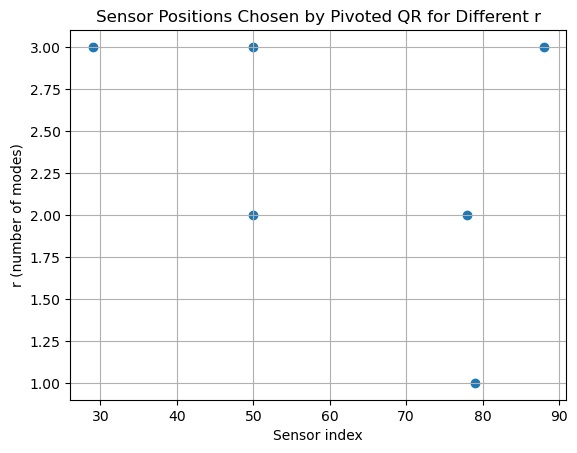

In [103]:
U, s, Vt = np.linalg.svd(W, full_matrices=False)


r_max = 3
r_start = 1
N = U.shape[0]  # number of spatial points (rows of U)

all_r = []
all_sensors = []

for r in range(r_start, r_max + 1):
    # Extract top-r modes from U
    U_r = U[:, :r]   # shape (N, r)

    # Pivoted QR on U_r^T (shape: r x N)
    Q, R, piv = la.qr(U_r.T, pivoting=True)

    # Pick the first r pivot indices => sensor locations
    sensor_indices = piv[:r]

    # Record each sensor index with its corresponding r
    for s_idx in sensor_indices:
        all_r.append(r)
        all_sensors.append(s_idx)

# Now make a scatter plot
plt.figure()
plt.scatter(all_sensors, all_r, marker='o')
plt.title("Sensor Positions Chosen by Pivoted QR for Different r")
plt.xlabel("Sensor index")
plt.ylabel("r (number of modes)")
plt.grid(True)
plt.show()

In [107]:
N, M = W.shape
print(f"Data loaded with shape W = {N} x {M}")

# Optionally, define the beam's spatial positions x_i for plotting
# (If you only have evenly spaced points and no physical length, just use range)
x_positions = np.linspace(0, 1, N)

Data loaded with shape W = 101 x 40001


Relative reconstruction error for snapshot 450: 1.6073e-13
Chosen r = 3


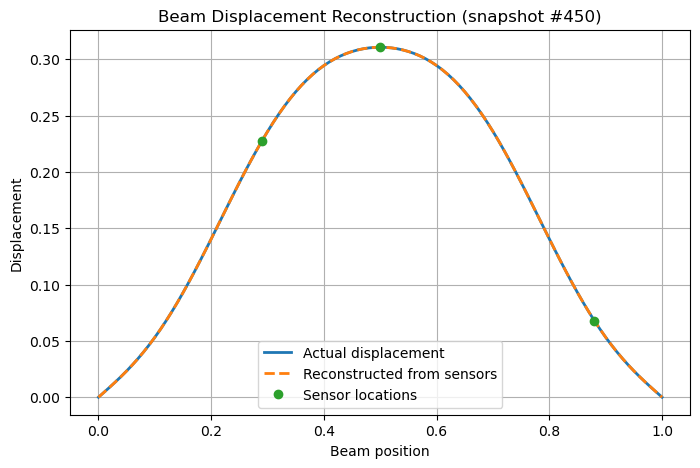

In [104]:
sensor_indices_sorted = np.sort(sensor_indices)
snapshot_index = 450 # choose any index in [0, M-1]
w_true = W[:, snapshot_index]  # This is the actual beam displacement at that snapshot
# In reality, you'd only measure w_true at the sensor locations below.

# The sensor measurements
w_sensor = w_true[sensor_indices]  # shape (r,)

# ---------------------------------------------------------------------
# 6) RECONSTRUCT THE BEAM DISPLACEMENT FROM THOSE SENSORS
# ---------------------------------------------------------------------
# Submatrix of U_r (only the rows = sensor_indices)
U_sub = U_r[sensor_indices, :]  # shape (r, r)

# Solve for modal coefficients alpha in a least-squares sense
# If U_sub is square (r x r) and invertible, we can do a direct solve:
alpha = np.linalg.solve(U_sub, w_sensor)
# (If you had more sensors than r, you'd use np.linalg.lstsq(U_sub, w_sensor).)

# Reconstruct the full shape
w_hat = U_r @ alpha  # shape (N,)

# ---------------------------------------------------------------------
# 7) COMPARE AND PLOT
# ---------------------------------------------------------------------
error = np.linalg.norm(w_hat - w_true) / np.linalg.norm(w_true)
print(f"Relative reconstruction error for snapshot {snapshot_index}: {error:.4e}")
print(f"Chosen r = {r}")

plt.figure(figsize=(8, 5))
plt.plot(x_positions, w_true, label="Actual displacement", linewidth=2)
plt.plot(x_positions, w_hat, "--", label="Reconstructed from sensors", linewidth=2)

# Mark sensor points on the plot
plt.plot(
    x_positions[sensor_indices_sorted],
    w_true[sensor_indices_sorted],
    "o",
    label="Sensor locations",
)

plt.title(f"Beam Displacement Reconstruction (snapshot #{snapshot_index})")
plt.xlabel("Beam position")
plt.ylabel("Displacement")
plt.legend()
plt.grid(True)
plt.show()

r=1, Mean Error=0.1584, % Snapshots Below Threshold=0.03%
r=2, Mean Error=0.0780, % Snapshots Below Threshold=12.18%
r=3, Mean Error=0.0000, % Snapshots Below Threshold=100.00%

Optimal r found: 3 sensors
Optimal sensor indices: [12 50 71]
Mean error for optimal r: 0.0000


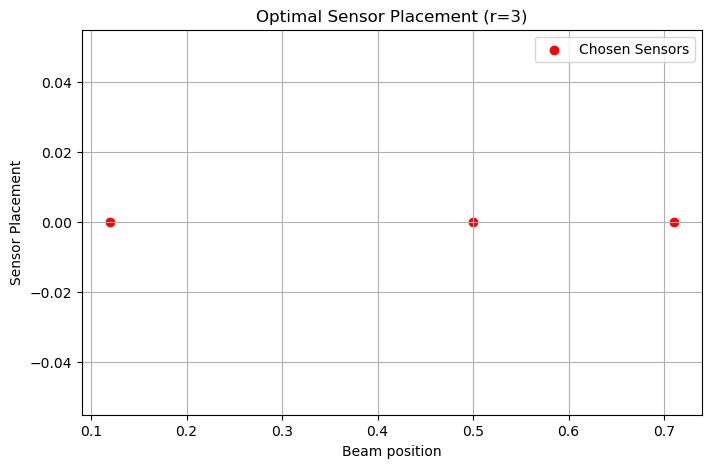

In [81]:
# Define error threshold
error_threshold = 0.005  # Allowable relative error (e.g., 5%)
required_snapshot_percentage = 0.99  # e.g., 95% of snapshots must satisfy the threshold

# --------------------------------------------------------------
# 3) Iterate Over Different r to Find Optimal Sensors
# --------------------------------------------------------------
best_r = None
best_sensors = None
best_error = None
r_min = 1

for r in range(r_min, N):  # Iterate over r from 1 to N
    # Extract r dominant modes
    U_r = U[:, :r]  # (N x r)

    # Perform pivoted QR to choose sensor locations
    Q, R, piv = la.qr(U_r.T, pivoting=True)
    sensor_indices = np.sort(piv[:r])  # Choose first r pivot indices (sorted)

    # ----------------------------------------------------------
    # 4) Reconstruct for All Snapshots and Compute Error
    # ----------------------------------------------------------
    errors = []
    
    for snapshot_index in range(M):  # Loop over all time snapshots
        w_true = W[:, snapshot_index]  # Ground truth displacement

        # Measure only at the chosen sensors
        w_sensor = w_true[sensor_indices]  # (r,)

        # Submatrix of U_r corresponding to selected sensors
        U_sub = U_r[sensor_indices, :]  # (r x r)

        # Solve for modal coefficients (least squares or direct)
        alpha = np.linalg.solve(U_sub, w_sensor)  

        # Reconstruct full displacement
        w_hat = U_r @ alpha  # (N,)

        # Compute relative error
        error = np.linalg.norm(w_hat - w_true) / np.linalg.norm(w_true)
        errors.append(error)

    # Compute the fraction of snapshots satisfying the error threshold
    valid_snapshots = np.sum(np.array(errors) <= error_threshold)
    fraction_valid = valid_snapshots / M

    print(f"r={r}, Mean Error={np.mean(errors):.4f}, % Snapshots Below Threshold={fraction_valid*100:.2f}%")

    # If this r is the first one meeting the criteria, store it as best
    if fraction_valid >= required_snapshot_percentage:
        best_r = r
        best_sensors = sensor_indices
        best_error = np.mean(errors)
        break  # Stop when we find the smallest valid r

# --------------------------------------------------------------
# 5) Output Results
# --------------------------------------------------------------
if best_r is not None:
    print(f"\nOptimal r found: {best_r} sensors")
    print(f"Optimal sensor indices: {best_sensors}")
    print(f"Mean error for optimal r: {best_error:.4f}")

    # Plot chosen sensor locations
    plt.figure(figsize=(8, 5))
    plt.scatter(x_positions[best_sensors], np.zeros_like(best_sensors), color="red", marker="o", label="Chosen Sensors")
    plt.xlabel("Beam position")
    plt.ylabel("Sensor Placement")
    plt.title(f"Optimal Sensor Placement (r={best_r})")
    plt.grid(True)
    plt.legend()
    plt.show()

else:
    print("No r found that meets the error criteria. Try adjusting the error threshold or snapshot percentage.")

In [86]:
max_deviation = np.max(W) - np.min(W)

In [87]:
max_deviation

129.79318091184

r=1, Max Error=0.3854, % Snapshots Below Threshold=2.28%
r=2, Max Error=0.0193, % Snapshots Below Threshold=96.29%
r=3, Max Error=0.0000, % Snapshots Below Threshold=100.00%
r=4, Max Error=0.0000, % Snapshots Below Threshold=100.00%
r=5, Max Error=0.0000, % Snapshots Below Threshold=100.00%
r=6, Max Error=0.0000, % Snapshots Below Threshold=100.00%
r=7, Max Error=0.0000, % Snapshots Below Threshold=100.00%
r=8, Max Error=0.0000, % Snapshots Below Threshold=100.00%
r=9, Max Error=0.0000, % Snapshots Below Threshold=100.00%


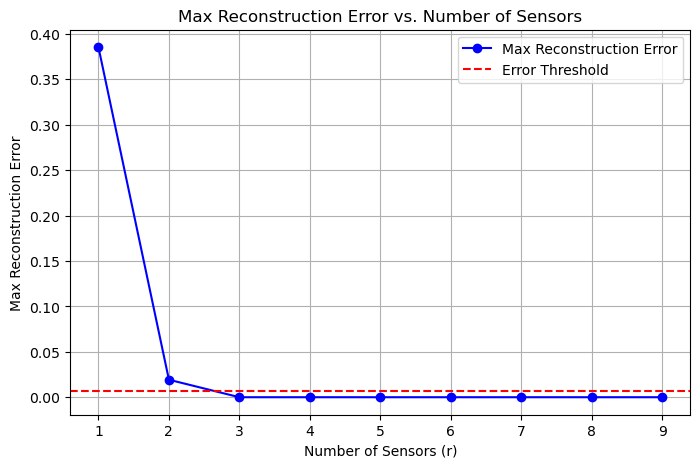


Optimal r found: 3 sensors
Optimal sensor indices: [29 50 88]
Max error for optimal r: 0.0000


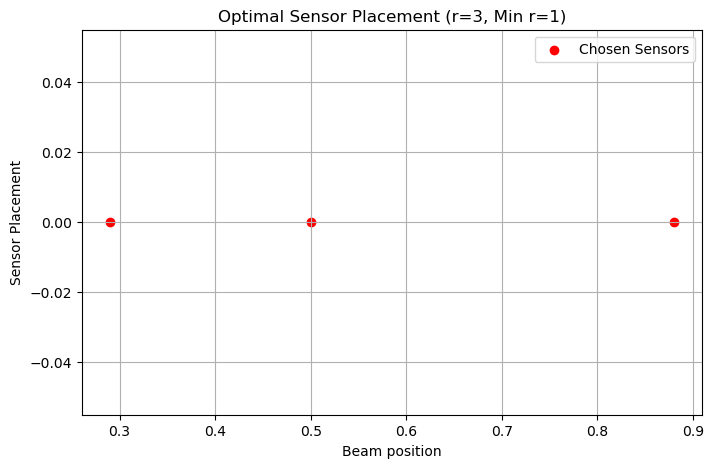

In [108]:
max_deviation = np.max(W) - np.min(W)
error_threshold = 0.0005*max_deviation  # Allowable relative error (e.g., 5%)
required_snapshot_percentage = 1  # e.g., 95% of snapshots must satisfy the threshold
r_min = 1  # Minimum number of sensors allowed (set this value as needed)

# --------------------------------------------------------------
# 3) Iterate Over Different r to Find Optimal Sensors (Ensuring r >= r_min)
# --------------------------------------------------------------
max_r = 10
max_snapshots = M
best_r = None
best_sensors = None
best_error = None

r_values = []  # Store r values
max_errors = []  # Store max reconstruction errors for each r

for r in range(r_min, max_r):  # Start at r_min instead of 1
    # Extract r dominant modes
    U_r = U[:, :r]  # (N x r)

    # Perform pivoted QR to choose sensor locations
    Q, R, piv = la.qr(U_r.T, pivoting=True)
    sensor_indices = np.sort(piv[:r])  # Choose first r pivot indices (sorted)

    # ----------------------------------------------------------
    # 4) Reconstruct for All Snapshots and Compute Error
    # ----------------------------------------------------------
    errors = []
    
    for snapshot_index in range(max_snapshots):  # Loop over all time snapshots
        w_true = W[:, snapshot_index]  # Ground truth displacement

        # Measure only at the chosen sensors
        w_sensor = w_true[sensor_indices]  # (r,)

        # Submatrix of U_r corresponding to selected sensors
        U_sub = U_r[sensor_indices, :]  # (r x r)

        # Solve for modal coefficients (least squares or direct)
        alpha = np.linalg.solve(U_sub, w_sensor)  

        # Reconstruct full displacement
        w_hat = U_r @ alpha  # (N,)

        # Compute relative error
        error = np.max(np.abs(w_hat - w_true))
        #print(error)
        errors.append(error)

    # Store max error for this r
    max_error = np.max(errors)
    r_values.append(r)
    max_errors.append(max_error)

    # Compute the fraction of snapshots satisfying the error threshold
    valid_snapshots = np.sum(np.array(errors) <= error_threshold)
    fraction_valid = valid_snapshots / M

    print(f"r={r}, Max Error={max_error:.4f}, % Snapshots Below Threshold={fraction_valid*100:.2f}%")

    # If this r is the first one meeting the criteria, store it as best
    if fraction_valid >= required_snapshot_percentage and best_r is None:
        best_r = r
        best_sensors = sensor_indices
        best_error = max_error

# --------------------------------------------------------------
# 5) Plot r vs. Max Reconstruction Error
# --------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(r_values, max_errors, marker="o", linestyle="-", color="b", label="Max Reconstruction Error")
plt.axhline(y=error_threshold, color="r", linestyle="--", label="Error Threshold")
plt.xlabel("Number of Sensors (r)")
plt.ylabel("Max Reconstruction Error")
plt.title("Max Reconstruction Error vs. Number of Sensors")
plt.legend()
plt.grid(True)
plt.show()

# --------------------------------------------------------------
# 6) Output Optimal Results
# --------------------------------------------------------------
if best_r is not None:
    print(f"\nOptimal r found: {best_r} sensors")
    print(f"Optimal sensor indices: {best_sensors}")
    print(f"Max error for optimal r: {best_error:.4f}")

    # Plot chosen sensor locations
    plt.figure(figsize=(8, 5))
    plt.scatter(x_positions[best_sensors], np.zeros_like(best_sensors), color="red", marker="o", label="Chosen Sensors")
    plt.xlabel("Beam position")
    plt.ylabel("Sensor Placement")
    plt.title(f"Optimal Sensor Placement (r={best_r}, Min r={r_min})")
    plt.grid(True)
    plt.legend()
    plt.show()

else:
    print(f"No r found that meets the error criteria with r >= {r_min}. Try adjusting the error threshold or snapshot percentage.")

In [ ]:
w_true